## Описание проекта

Требуется разработать модель машинного обучения, которая будет предсказывать риск возникновения сердечного приступа (бинарный классификатор). Для этой модели нужно подготовить библиотеку и интерфейс к ней. Для обучения модели предоставлен датасет, на котором нужно обучить модель делать предсказания. Датасет содержит информацию о 8600 пациентах (антропометрические параметры, привычки, образ жизни, давление, наличие хронических заболеваний, биохимия крови). Также предоставлен тестовый датасет, на котором нужно сделать обучнной моделью предсказание риска сердечного приступа. При этом правильные ответы для тестовой выборки исполнителю неизвестны.

## Обзор предметной области: определения и факторы риска

**Сердечный приступ (или инфаркт миокарда)** — это серьезное медицинское состояние, которое возникает, когда приток крови к части сердца внезапно блокируется. Чаще всего это происходит из-за образования тромба в одной из коронарных артерий, которые снабжают сердце кровью. Без достаточного притока крови сердечная мышца начинает отмирать.<br>

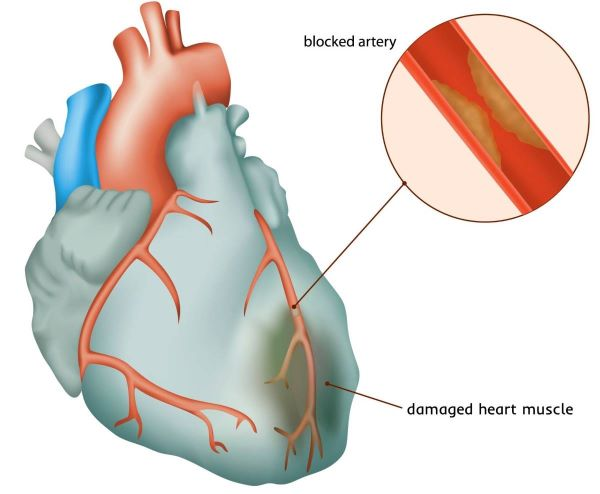

**Причины:**<br>

* Основная причина — атеросклероз, при котором в артериях накапливаются жировые отложения (бляшки). Эти бляшки могут разрываться, вызывая образование тромба, который блокирует кровоток.<br>
* Реже причиной может быть спазм коронарной артерии, который сужает ее и ограничивает приток крови.<br>

**Факторы риска:**<br>

* Высокое кровяное давление (гипертония).
* Высокий уровень холестерина.
* Диабет.
* Курение.
* Ожирение.
* Недостаток физической активности.
* Стресс.
* Семейный анамнез (генетическая предрасположенность).
* Возраст (риск увеличивается с возрастом).

**Способы диагностирования сердечного приступа:**<br>

* ***КФК-МВ (креатинфосфокиназа-МВ)*** — это один из изоферментов фермента креатинфосфокиназы (КФК), который содержится преимущественно в сердечной мышце (миокарде). Измерение уровня КФК-МВ в крови является важным диагностическим тестом, особенно при подозрении на повреждение сердечной мышцы, при инфаркте миокарда (сердечном приступе). Когда клетки сердечной мышцы повреждаются или отмирают (что происходит во время инфаркта), КФК-МВ высвобождается в кровоток.<br>

    Уровень КФК-МВ начинает повышаться в крови через 3-6 часов после начала инфаркта миокарда. Достигает пика через 12-24 часа. Возвращается к норме в течение 24-48 часов. Таким образом, КФК-МВ — это биомаркер, который указывает на повреждение сердечной мышцы, и его уровень в крови помогает врачам диагностировать сердечный приступ. Хотя КФК-МВ является полезным маркером, сейчас чаще используют более специфичный и чувствительный маркер — ***тропонин***.<br>
    
* ***Тропонин*** остается повышенным в крови дольше (до 10-14 дней), что позволяет диагностировать инфаркт даже спустя несколько дней после его начала. Однако КФК-МВ все еще может использоваться в комбинации с тропонином или для выявления повторного инфаркта, так как его уровень быстрее нормализуется.<br>

<font color='darkred'>❗ Таким образом, эти маркеры используются для диагностики инфаркта, а не для оценки риска его возникновения. Риск инфаркта оценивается по другим показателям и факторам (например, уровень холестерина, артериальное давление, наличие диабета, курение и т.д.).</font>

**Информация о приеме лекарственных средств:**<br>
При разработке моделей машинного обучения важно учитывать, принимает ли пациент какие-либо лекарственные препараты, так как это напрямую может влиять на значения биомаркеров в крови.<br>

Например:<br>
* Если у пациента низкий уровень холестерина, но он принимает статины, это нормальное состояние на фоне терапии, а не естественный низкий уровень.
* Измененные показатели калия или креатинина могут быть связаны с приемом ингибиторов АПФ/БРА или диуретиков, а не с ухудшением функции почек или дисбалансом электролитов, вызванным другими причинами.
* Изменение показателей свертываемости крови будет ожидаемым при приеме антитромботических средств.<br>

<font color='darkred'>Игнорирование информации о принимаемых лекарствах может привести к неверным выводам, искаженным зависимостям в данных и, как следствие, к менее точным или даже ошибочным предсказаниям модели. При возможности рекомендуется включить информацию о принимаемых лекарствах в качестве признаков, или учитывать их влияние при интерпретации других признаков.</font>

**Лекарства, используемые для снижения риска инфаркта и после инфаркта:**<br>

**1. Антитромботические препараты (антиагреганты и антикоагулянты):**<br>

* Примеры: Аспирин, клопидогрел, тикагрелор, варфарин, новые оральные антикоагулянты (НОАК).
* Цель: Предотвращение образования тромбов, которые могут блокировать коронарные артерии или вызвать повторный инфаркт.
* Потенциальное влияние на анализ крови: Могут влиять на показатели свертываемости крови (например, INR для варфарина, время кровотечения).<br>

**2. Статины (ингибиторы ГМГ-КоА-редуктазы):**<br>

* Примеры: Аторвастатин, розувастатин, симвастатин.
* Цель: Снижение уровня холестерина липопротеинов низкой плотности (ЛПНП) — «плохого» холестерина, который является ключевым фактором развития атеросклероза.
* Потенциальное влияние на анализ крови: Значительно снижают уровень общего холестерина и ЛПНП. Могут повышать уровень печеночных ферментов (АЛТ, АСТ) и креатинфосфокиназы (КФК), что требует мониторинга.<br>

**3. Бета-блокаторы:**<br>

* Примеры: Метопролол, бисопролол, карведилол.
* Цель: Снижение частоты сердечных сокращений и артериального давления, уменьшение нагрузки на сердце. Используются после инфаркта для предотвращения повторных событий и лечения хронической сердечной недостаточности.
* Потенциальное влияние на анализ крови: Могут незначительно влиять на уровень глюкозы в крови у пациентов с диабетом, маскировать симптомы гипогликемии. Редко могут повышать уровень ***триглицеридов*** и снижать ЛПВП.<br>

**4. Ингибиторы АПФ (ангиотензинпревращающего фермента) и блокаторы рецепторов ангиотензина II (БРА):**<br>

* Примеры ингибиторов АПФ: Эналаприл, лизиноприл, рамиприл.
* Примеры БРА: Валсартан, лозартан, кандесартан.
* Цель: Снижение артериального давления, защита почек, предотвращение ремоделирования сердца после инфаркта.
* Потенциальное влияние на анализ крови: Могут повышать уровень калия в крови (гиперкалиемия) и креатинина (показатель функции почек). Это тоже важные параметры для мониторинга.<br>

**5. Диуретики (мочегонные средства):**<br>

* Примеры: Гидрохлоротиазид, фуросемид.
* Цель: Снижение артериального давления и уменьшение отеков при сердечной недостаточности.
* Потенциальное влияние на анализ крови: Могут снижать уровень калия (гипокалиемия) и натрия, повышать уровень глюкозы, мочевой кислоты и кальция.<br>


**Список признаков в датасетах**

| **Название столбца**       | **Перевод**       |
|:---------------------------|:------------------|
|<font color='darkred'>`Heart Attack Risk (Binary)`</font> | <font color='darkred'>Риск сердечного приступа (целевой)</font>|
| `Age`                      | Возраст           |
| `Cholesterol`              | Холестерин        |
| `Heart rate`               | Частота сердцебиения |
| `Diabetes`                 | Диабет            |
| `Family History`           | Семейный анамнез  |
| `Smoking`                  | Курение           |
| `Obesity`                  | Ожирение          |
| `Alcohol Consumption`      | Употребление алкоголя |
| `Exercise Hours Per Week`  | Часы тренировок в неделю |
| `Diet`                     | Диета             |
| `Previous Heart Problems`  | Предыдущие проблемы с сердцем |
| `Medication Use`           | Использование лекарств |
| `Stress Level`             | Уровень стресса   |
| `Sedentary Hours Per Day`  | Часы сидячего образа жизни в день |
| `Income`                   | Доход             |
| `BMI`                      | ИМТ (Индекс массы тела) |
| `Triglycerides`            | Триглицериды      |
| `Physical Activity Days Per Week` | Дни физической активности в неделю |
| `Sleep Hours Per Day`      | Часы сна в день   |
| `Blood sugar`              | Уровень сахара в крови |
| `CK-MB`                    | КФК-МВ (креатинфосфокиназа-МВ) |
| `Troponin`                 | Тропонин          |
| `Gender`                   | Пол               |
| `Systolic blood pressure`  | Систолическое артериальное давление |
| `Diastolic blood pressure` | Диастолическое артериальное давление |

## Загрузка данных

In [1]:
# Установка необходимых библиотек
!pip install phik -q
!pip install catboost==1.2.8 -q

In [2]:
# Импорт библиотек для работы с данными и визуализации
import numpy as np
import pandas as pd
import phik
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool

In [3]:
# Установим отображение всех столбцов
pd.set_option('display.max_columns', None)

In [4]:
# Загружаем датасеты
test = pd.read_csv('https://storage.yandexcloud.net/ds-datasets-1/heart_test.csv')
train = pd.read_csv('https://storage.yandexcloud.net/ds-datasets-1/heart_train.csv')

Создадим копии датасетов, с которыми будем проводить все операции в процессе исследовательского анализа данных, так как для этого понадобится преобразование форматов данных. А исходные датасеты будем обрабатывать с помощью пайплайнов.

In [5]:
# Создаем копии датасетов для анализа
df_test = test.copy()
df_train = train.copy()

In [6]:
# Проверяем результат загрузки
df_train.head(5)

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


In [7]:
# Проверяем результат загрузки
df_test.head(5)

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.587759,0.283490,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.602883,0.467036,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.370436,0.409366,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.368242,0.910261,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.729578,0.758924,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825


Датасеты загрузились верно. Но по первым строкам видно, что данные уже преобразованы, предположительно методом MinMax. В тестовом датасете в признаке `Sleep Hours Per Day` в 5-ой строке есть нулевое значение. Вполне возможно, что это неявное пропущенное значение. Проверим это в разделе исследовательского анализа аднных. А сейчас посмотрим общую информацию о датасетах, и заодно проверим, в каком формате представлены признаки.

In [8]:
# Выведем информацию о тренировочном датасете
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

In [9]:
# Выведем информацию о тестовом датасете
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       966 non-null    int64  
 1   Age                              966 non-null    float64
 2   Cholesterol                      966 non-null    float64
 3   Heart rate                       966 non-null    float64
 4   Diabetes                         935 non-null    float64
 5   Family History                   935 non-null    float64
 6   Smoking                          935 non-null    float64
 7   Obesity                          935 non-null    float64
 8   Alcohol Consumption              935 non-null    float64
 9   Exercise Hours Per Week          966 non-null    float64
 10  Diet                             966 non-null    int64  
 11  Previous Heart Problems          935 non-null    float64
 12  Medication Use        

В тренировочном датасете содержится информация о 8685 пациентах. В тестовом датасете 966 строк с информацией о пациентах. Почти все признаки в обоих датасетах имеют числовой тип данных *float64*, в том числе и категориальные признаки. Три признака (`Unnamed: 0`, `Diet`, `id`) представлены целочисленным типом *int64*. Скорее всего признак `Unnamed: 0` это инкриментный первичный ключ из исходной базы данных, и он не имеет смысла в данном исследовании. Удалять его не будем, просто проигнорируем его при построении пайплайна. Один категориальный признак `Gender` принадлежит строковому типу.<br>

### Вывод по разделу

* Заказчиком предоставлены уже разделенная выборка не тестовые и тренировочные данные.
* Тренировочный датасет содержит 8685 строк, тетосовый 966 строк.
* В обоих датасетах имеются пропуски.

## Предобработка данных

### Проверка на data leakage тренировочного датасета

Так как в задании предоставлены уже разделенные тренировочная и тестовая выборки, то нужно проверить, чтобы пациенты (по полю id) из тестовой выборки не попали по ошибке в тренировочную выборку, то есть проверим на наличие data leakage.

In [10]:
# Проверяем наличие id из тестовой выборки в тренировочной выборке
df_test['id'].isin(df_train['id']).sum()

np.int64(0)

Утечки данных не обнаружено.

### Проверка неизвестных признаков

На этапе загрузки данных мы выявили неизвестный признак `Unnamed: 0`, который похож на инкриментный первичный ключ из исходной базы данных, и он не имеет смысла в данном исследовании. Проверим с помощью гистограммы, распределение значений признака `Unnamed: 0`.

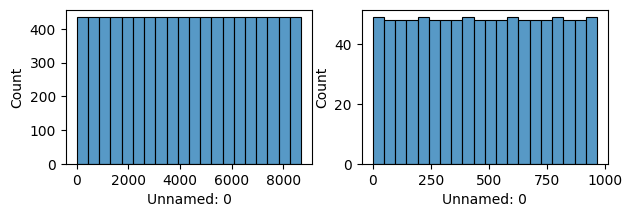

In [11]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(7,2))
sns.histplot(data=df_train, x='Unnamed: 0', bins=20, ax=ax1)
sns.histplot(data=df_test, x='Unnamed: 0', bins=20, ax=ax2)
plt.show()

Предположение верно, этот признак `Unnamed: 0` мы исключим из обучения. Этот признак будем обработывать с помощью пайплайна. Если такой признак будет попадать на вход, пайплайн будет его удалять.<br>
Сейчас, для целей анализа этот признак удалим вручную из копии датасета.

In [12]:
# Удаляем ненужный столбец
df_train.drop(columns='Unnamed: 0', inplace=True)

### Преобразование типов данных

Очевидно, что из-за наличия пропусков категориальные данные в числовом формате преобразовались в тип `float`, так как тип `int` не позволяет хранить значения NaN. В формате `int` остался только признак `Diet`, так как в нем нет пропусков. Поэтому преобразуем эти данные в категориальный формат через промежуточное преобразование в текстовый формат. При этом нужно учитывать, что в при преобразовании в текстовый формат значения NaN преобразуются в текст "nan", поэтому после преобразования сделаем замены.<br>

Предварительно создадим список признаков категориального типа.

In [13]:
# Создаем список категориальных признаков
cat_features = ['Diabetes', 'Family History', 'Smoking', 'Obesity',
                'Alcohol Consumption', 'Diet', 'Previous Heart Problems',
                'Medication Use', 'Stress Level', 'Gender',
                'Physical Activity Days Per Week']

# Преобразуем входные признаки в категориальный тип
df_train[cat_features] = df_train[cat_features].astype(str).replace("nan", pd.NA).astype('category')
df_test[cat_features] = df_test[cat_features].astype(str).replace("nan", pd.NA).astype('category')

Преобразуем целевой признак из float в категориальный тип к виду 1/0.

In [14]:
# Преобразуем целевой признак в категориальный тип
df_train['Heart Attack Risk (Binary)'] = (
    df_train['Heart Attack Risk (Binary)'].astype(int)
)

### Обработка пропусков

Несколько признаков в обоих датасетах имеют пропуски значений. Посмотрим детальнее в каких признаках имеются пропуски и сколько их. Напишем для этого небольшую функцию.

In [15]:
# Считает кол-во пропусков во всех столбцах датафрейма
def nan_count(df):
    for col_name in df.columns:
        nan_sum = df[col_name].isna().sum()
        if nan_sum != 0:
            print(f"Пропущено значений в '{col_name}' - {nan_sum}")

In [16]:
# Посчитаем кол-во пропусков в тренировочном датасете
nan_count(df_train)

Пропущено значений в 'Diabetes' - 243
Пропущено значений в 'Family History' - 243
Пропущено значений в 'Smoking' - 243
Пропущено значений в 'Obesity' - 243
Пропущено значений в 'Alcohol Consumption' - 243
Пропущено значений в 'Previous Heart Problems' - 243
Пропущено значений в 'Medication Use' - 243
Пропущено значений в 'Stress Level' - 243
Пропущено значений в 'Physical Activity Days Per Week' - 243


In [17]:
# Посчитаем кол-во пропусков в тестовом датасете
nan_count(df_test)

Пропущено значений в 'Diabetes' - 31
Пропущено значений в 'Family History' - 31
Пропущено значений в 'Smoking' - 31
Пропущено значений в 'Obesity' - 31
Пропущено значений в 'Alcohol Consumption' - 31
Пропущено значений в 'Previous Heart Problems' - 31
Пропущено значений в 'Medication Use' - 31
Пропущено значений в 'Stress Level' - 31
Пропущено значений в 'Physical Activity Days Per Week' - 31


<font color='darkred'>В разделе обзора предметной области описывалось, что все эти признаки, которые имеют пропуски, являются очень важными факторами риска возникновения сердечного приступа. И очевидно, что отсутствие любого из этих признаков может существенно исказить результаты предсказания рабочей модели. Отсутсвие любого из этих признаков может расцениваться как значение `0` и модель может сделать предсказание отсутствия риска приступа, тогда как он фактически у пациента будет высоким. Заполнять подобные пропуски медианой тоже нельзя, поскольку очень высока цена ошибки в случае неправильного заполнения. Правильно будет вообще не делать предсказания по таким пациентам, а оставить принятие решения по такому пациенту доктору. Ведь в любом случае, ответственность за неправильный диагноз ложится на доктора, поэтому модель должна помогать достоверно помогать определять всех пациентов с высоким риском инфаркта.</font><br>

Пропуски встречаются в одних и тех же признаках в обоих датафреймах. Кол-во пропусков в каждом столбце одинаково. Можно предположить, что у всех этих пропусков одна причина. Выведем несколько строк, в которых встречаются пропуски.

In [18]:
# Выводим первые строки с пропусками
df_train[df_train.isnull().any(axis=1)].head()

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
16,0.449438,0.49978,0.063245,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0,0.233202,0.026692,0.000777,1.0,0.393548,0.255814,9528
90,0.370787,0.49978,0.066911,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0,0.154150,0.004702,0.042043,1.0,0.258065,0.337209,9640
92,0.629213,0.49978,0.073327,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0,0.256917,0.012310,0.000777,0.0,0.258065,0.232558,9515
185,0.516854,0.49978,0.045830,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0,0.559289,0.006704,0.000291,0.0,0.174194,0.151163,9491
188,0.269663,0.49978,0.035747,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0,0.112648,0.051218,0.000485,0.0,0.225806,0.162791,9448


In [19]:
# Выводим первые строки с пропусками
df_test[df_test.isnull().any(axis=1)].head()

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
27,27,0.370787,0.49978,0.034830,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0.181818,0.011843,0.000194,1.0,0.419355,0.441860,9613
37,37,0.573034,0.49978,0.043080,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0.167984,0.011209,0.000971,1.0,0.722581,0.732558,9471
58,58,0.516854,0.49978,0.045830,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0.098814,0.036436,0.002233,1.0,0.387097,0.500000,9486
60,60,0.370787,0.49978,0.056829,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0.199605,0.005970,0.006408,1.0,0.387097,0.220930,9391
61,61,0.483146,0.49978,0.028414,NaN,NaN,NaN,NaN,NaN,0.50211,3,NaN,NaN,NaN,0.49992,0.494889,0.494774,0.503603,NaN,0.504621,0.112648,0.013111,0.000680,1.0,0.419355,0.325581,9579


Посмотрим, все ли эти пропуски относятся одновременно к одному объекту наблюдения (строке) или разбросаны между разными объектами? Посчитаем все строки, которые содержат хотя бы один пропуск.

In [20]:
# Считаем все строки с хотя бы одним пустым значением
print('\033[1m' + 'Общее количество всех строк с пропусками:' + '\033[0m', len(df_train[df_train.isnull().any(axis=1)]))
print('\033[1m' + 'Общее количество всех строк с пропусками:' + '\033[0m', len(df_test[df_test.isnull().any(axis=1)]))


Общее количество всех строк с пропусками: 243
Общее количество всех строк с пропусками: 31


Общее количество строк с пропусками совпадает с количеством пропусков по каждому признаку. Другими словами, в тестовом датасете есть 243 объекта, в которых отсутствует информация одновременно по 9 признакам. А в тестовом датасете таких признаков - 31. Какую-то зависимость в пропущенных данных сложно определить. Не похоже, что эти данные были не заполнены пациентом. Скорее всего данные были утеряны при обработке данных (в процессе загрузки или выгрузки из базы).<br>
Также можно заметить, что еще 8 признаков: `Sleep Hours Per Day`, `Exercise Hours Per Week`, `Diet`, `Sedentary Hours Per Day`, `Income`, `BMI`, `Triglycerides`, `Sleep Hours Per Day` имеют одинаковые в обоих датасетах константные значения.<br>
Эти строки с пропущенными значениями удалять не сейчас не будем, а попробуем найти причины таких пропусков, и при возможности восстановить пропущенные значения.<br>

Посмотрим, сколько строк с пропущенными значениями в процентном выражении в каждом датасете.

In [21]:
#Считаем долю строк с пропусками
perc_nan_train = (len(df_train[df_train.isnull().any(axis=1)]) / len(df_train)) * 100
print(f"Процент строк пропусками в df_train: {perc_nan_train:.2f}%")

perc_nan_test = (len(df_test[df_test.isnull().any(axis=1)]) / len(df_test)) * 100
print(f"Процент строк пропусками в df_test: {perc_nan_test:.2f}%")

Процент строк пропусками в df_train: 2.80%
Процент строк пропусками в df_test: 3.21%


Данных с пропусками всего около 3%. Скорее всего эти данные не несут ценности для обучения модели, и их можно будет удалить. Но сначала проверим датасеты на наличие дубликатов.

### Поиск явных дубликатов

Теперь проверим наличие строк дубликатов. Очевидно, что только поле `id` должно быть уникальным. Поэтому наличие дубликатов будем проверять только по этому полю.

In [22]:
# проверим наличие дубликатов по полю 'id'
print('Количество дубликатов по полю id в df_train:', df_train['id'].duplicated().sum())
print('Количество дубликатов по полю id в df_test:', df_test['id'].duplicated().sum())


Количество дубликатов по полю id в df_train: 0
Количество дубликатов по полю id в df_test: 0


Дубликатов в обоих датасетах не обнаружено. Это поле имеет целочисленный тип, что исключает наличие неяных дубликатов.

### Поиск неявных дубликатов

Проведем поиск неявных дубликатов в категориальных признаках. Создадим для этого функцию, которая будет выводить все уникальные значения и пропуски значений в категориальных признаках в датафрейме.

In [23]:
# функция считает уникальные значения и пропуски категориальных признаков в датафрейме
def count_unique(df):
    for column in df.columns:
        print('\033[1m' + f"Распределение значений в столбце '{column}':" + '\033[0m')
        value_counts = df[column].value_counts(dropna=False)
        print(value_counts.to_string())
        missing_count = df[column].isnull().sum()
        print()  # Пустая строка для разделения
    print('='*55)

In [24]:
# Выведем уникальные значения категориальных признаков
count_unique(df_train[cat_features])

Распределение значений в столбце 'Diabetes':
Diabetes
1.0    5505
0.0    2937
NaN     243

Распределение значений в столбце 'Family History':
Family History
0.0    4309
1.0    4133
NaN     243

Распределение значений в столбце 'Smoking':
Smoking
1.0    7622
0.0     820
NaN     243

Распределение значений в столбце 'Obesity':
Obesity
0.0    4235
1.0    4207
NaN     243

Распределение значений в столбце 'Alcohol Consumption':
Alcohol Consumption
1.0    5082
0.0    3360
NaN     243

Распределение значений в столбце 'Diet':
Diet
1    2863
2    2796
0    2783
3     243

Распределение значений в столбце 'Previous Heart Problems':
Previous Heart Problems
0.0    4260
1.0    4182
NaN     243

Распределение значений в столбце 'Medication Use':
Medication Use
1.0    4231
0.0    4211
NaN     243

Распределение значений в столбце 'Stress Level':
Stress Level
7.0     869
4.0     857
2.0     854
9.0     852
8.0     844
3.0     841
1.0     840
5.0     833
6.0     828
10.0    824
NaN     243

Распредел

In [25]:
# Выведем уникальные значения категориальных признаков
count_unique(df_test[cat_features])

Распределение значений в столбце 'Diabetes':
Diabetes
1.0    614
0.0    321
NaN     31

Распределение значений в столбце 'Family History':
Family History
0.0    485
1.0    450
NaN     31

Распределение значений в столбце 'Smoking':
Smoking
1.0    840
0.0     95
NaN     31

Распределение значений в столбце 'Obesity':
Obesity
1.0    483
0.0    452
NaN     31

Распределение значений в столбце 'Alcohol Consumption':
Alcohol Consumption
1.0    546
0.0    389
NaN     31

Распределение значений в столбце 'Diet':
Diet
0    322
2    312
1    301
3     31

Распределение значений в столбце 'Previous Heart Problems':
Previous Heart Problems
0.0    473
1.0    462
NaN     31

Распределение значений в столбце 'Medication Use':
Medication Use
0.0    478
1.0    457
NaN     31

Распределение значений в столбце 'Stress Level':
Stress Level
2.0     107
4.0     103
1.0     100
8.0      99
7.0      95
5.0      95
3.0      87
6.0      86
10.0     84
9.0      79
NaN      31

Распределение значений в столбце '

Также, можно обратить внимание, что только в признаке `Gender` есть неявные дубликаты.<br>
Поле `Gender` со значениями `0` и `1` встречалось в строках с пропусками NaN, а в строках без пропусков были значения `Male` и `Female`. По сумме количество строк со значениями `0` и `1` совпадает с количеством пропусков в каждом датасете. Скорее всего значения `0` и `1` встречаются только в строках с пропусками.<br>
Чаще всего в машинном обучении и статистике, если речь идет о бинарной кодировке пола в виде `0` и `1`, то `0` часто присваивается значению `Female` (Женский пол), `1` часто присваивается `Male` (Мужской пол). Однако, это не является строгим правилом, и может быть наоборот. В датасетах значение `Male` встречается чаще в 2 раза, чем `Female`, и также значение `1` встречается чаще в 2 раза, чем `0`. Это тоже склоняет в  пользу утверждения, что `1` это `Male`. Попробуем удостовериться в этом с помощью взаимосвязи с другими признаками.

Посмотрим корреляцию признака `Gender` с другими признакми с помощью матрицы корреляции Phik. Но выведем только наш признак. Для этого построим матрицу корреляции Phik. Далее в разделе исследовательского анализа данных выведем матрицу корреляции по всем признакам.

In [26]:
# Создадим список количественных признаков для матрицы
interval_cols = list(
    df_train.drop(columns=cat_features)
    .drop(columns=['id', 'Heart Attack Risk (Binary)'])
    .columns
)

In [27]:
# Вычисляем матрицу Phik корреляции
phik_matrix = phik.phik_matrix(
    df=df_train.drop(columns=['id']),
    interval_cols=interval_cols
)

In [28]:
# Выводим столбец 'Gender' из матрицы
(
    phik_matrix[['Gender']]
    .style
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
    .background_gradient(cmap='coolwarm', axis=None)
    .format('{:.2f}')
)

,Gender
Age,0.16
Cholesterol,0.39
Heart rate,0.21
Diabetes,0.01
Family History,0.01
Smoking,0.70
Obesity,0.00
Alcohol Consumption,0.01
Exercise Hours Per Week,0.41
Diet,0.90


Наибольшую корреляцию с признаком `Gender` имеет признак `Diet`. Посмотрим, как распределены значения признака `Diet` в разрезе пола.

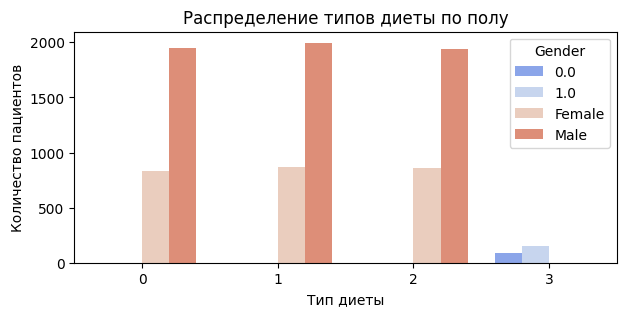

In [29]:
# График зависимости 'Gender' от 'Diet'
plt.figure(figsize=(7, 3))
sns.countplot(data=df_train, x='Diet', hue='Gender', palette='coolwarm')
plt.title('Распределение типов диеты по полу')
plt.xlabel('Тип диеты')
plt.ylabel('Количество пациентов')
plt.show()

Значение `3` из признака `Diet` принадлежит только значениям `1` и `0`  из признака `Gender` , то есть только строкам с пропусками. Можно предположить, что значение `3` использовалось в качестве заглушки для пропусков, так как в этом признаке нет пропусков. Значит, для этих строк признак `Diet` не несет ценности, хотя очевидно, что диета пациента тоже может быть фактором развития сердечного приступа.<br>
Очевидно, что строки с пропусками нужно удалить из датасета и не пытаться их восстановить, так как большая часть информации в этих строках отсутсвует, а та информация, которая есть, заполнена по большей части константными значениями. Также такие строки будут сильно искажать коэфиициенты корреляции признаков.

In [30]:
# Удаляем строки с пропусками
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

### Вывод по разделу

* Проведена проверка на утечку данных (попадание сотрудников из тренировочной выборки в тестовую). Утечки данных не обнаружено.
* В датасетах были удалены столбцы с индексами из базы данных `Unnamed: 0`
* Количественные признаки преобразованы к типа 'float', категориальные признакми к типу 'category'
* В обоих датасетах есть пропуски в признаках: 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Physical Activity Days Per Week'.
* Строки с пропуками были удалены из датасета для обучения модели.

## Исследовательский анализ данных

Для удобства скопируем описание всех признаков в начале этого раздела.

**Описание признаков в датасетах**

| **Название признака**       | **Перевод**       | **Тип признака** |
|:---------------------------|:------------------|:-------------|
|<font color='darkred'>`Heart Attack Risk (Binary)`</font> | <font color='darkred'>Риск сердечного приступа (бинарный)</font>| <font color='darkred'>Категориальный (float64)</font> |
| `Age`                      | Возраст           | float64 |
| `Cholesterol`              | Холестерин        | float64 |
| `Heart rate`               | Частота сердцебиения | float64 |
| `Diabetes`                 | Диабет            | Категориальный (float64) |
| `Family History`           | Семейный анамнез  | Категориальный (float64) |
| `Smoking`                  | Курение           | Категориальный (float64) |
| `Obesity`                  | Ожирение          | Категориальный (float64) |
| `Alcohol Consumption`      | Употребление алкоголя | Категориальный (float64) |
| `Exercise Hours Per Week`  | Часы тренировок в неделю | float64 |
| `Diet`                     | Диета             | Категориальный (int64) |
| `Previous Heart Problems`  | Предыдущие проблемы с сердцем | Категориальный (float64) |
| `Medication Use`           | Использование лекарств | Категориальный (float64) |
| `Stress Level`             | Уровень стресса   | Категориальный (float64) |
| `Sedentary Hours Per Day`  | Часы сидячего образа жизни в день | float64 |
| `Income`                   | Доход             | float64 |
| `BMI`                      | ИМТ (Индекс массы тела) | float64 |
| `Triglycerides`            | Триглицериды      | float64 |
| `Physical Activity Days Per Week` | Дни физической активности в неделю | Категориальный (float64) |
| `Sleep Hours Per Day`      | Часы сна в день   | float64 |
| `Blood sugar`              | Уровень сахара в крови | float64 |
| `CK-MB`                    | КФК-МВ (креатинфосфокиназа-МВ) | float64 |
| `Troponin`                 | Тропонин          | float64 |
| `Gender`                   | Пол               | Категориальный |
| `Systolic blood pressure`  | Систолическое артериальное давление | float64 |
| `Diastolic blood pressure` | Диастолическое артериальное давление | float64 |
| `id`                       | Идентификатор пациента    | int64 |

Построим заново матрицу корреляции признаков после удаления строк с пропусками.

In [31]:
# Вычисляем матрицу Phik корреляции
phik_matrix = phik.phik_matrix(
    df=df_train.drop(columns=['id']),
    interval_cols=interval_cols
)

# Отобразим матрицу корреляции
(
    phik_matrix
    .style
    .background_gradient(cmap='coolwarm', axis=None)
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'th.col_heading', 'props': [
            ('writing-mode', 'vertical-rl'),
            ('transform', 'rotateZ(180deg)'),
            ('height', '120px'),
            ('vertical-align', 'bottom')
        ]}
    ])
    .format('{:.2f}')
    .set_caption('Матрица корреляции (Phik) количественных и категориальных признаков')
)

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
Age,1.00,0.05,0.10,0.04,0.00,0.62,0.00,0.00,0.00,0.03,0.00,0.01,0.05,0.03,0.00,0.02,0.06,0.01,0.03,0.02,0.36,0.14,0.12,0.01,0.03,0.04
Cholesterol,0.05,1.00,0.05,0.03,0.00,0.03,0.00,0.05,0.06,0.00,0.00,0.00,0.05,0.05,0.04,0.02,0.07,0.01,0.03,0.00,0.00,0.04,0.02,0.03,0.05,0.05
Heart rate,0.10,0.05,1.00,0.02,0.00,0.03,0.00,0.00,0.00,0.01,0.02,0.00,0.06,0.07,0.06,0.05,0.00,0.02,0.04,0.01,0.36,0.14,0.10,0.01,0.04,0.04
Diabetes,0.04,0.03,0.02,1.00,0.03,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.01,0.01,0.04,0.01,0.03,0.02,0.00,0.00,0.03,0.01,0.04,0.03
Family History,0.00,0.00,0.00,0.03,1.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.02,0.01,0.03,0.02,0.00,0.03,0.02,0.00,0.03,0.02,0.00,0.01,0.03,0.02
Smoking,0.62,0.03,0.03,0.00,0.00,1.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.01,0.00,0.01,0.03,0.00,0.01,0.00,0.12,0.02,0.03,0.70,0.00,0.00
Obesity,0.00,0.00,0.00,0.02,0.01,0.00,1.00,0.02,0.06,0.00,0.00,0.00,0.04,0.03,0.00,0.00,0.01,0.02,0.00,0.02,0.00,0.02,0.02,0.00,0.03,0.05
Alcohol Consumption,0.00,0.05,0.00,0.00,0.01,0.00,0.02,1.00,0.00,0.01,0.00,0.00,0.00,0.05,0.03,0.01,0.03,0.02,0.00,0.01,0.00,0.00,0.01,0.01,0.00,0.00
Exercise Hours Per Week,0.00,0.06,0.00,0.00,0.00,0.01,0.06,0.00,1.00,0.02,0.03,0.00,0.06,0.05,0.08,0.03,0.06,0.02,0.03,0.00,0.01,0.00,0.00,0.03,0.03,0.05
Diet,0.03,0.00,0.01,0.00,0.00,0.01,0.00,0.01,0.02,1.00,0.03,0.02,0.01,0.00,0.01,0.01,0.04,0.03,0.02,0.02,0.04,0.00,0.02,0.01,0.03,0.00


На матрице можно обратить внимание, что целевой признак имеет практичеки нулевую корреляцию со всеми входными признаками. Однозначно, что тут не подойдут линейные модели. Для таких данных можно поробовать ансамблевые модели бустинга.

Все количественные данные были предоставлены уже отмасштабированными с помощью трансформера MinMax. Преобразовать обратно без знания максимальной и минимальной величины невозможно. Для модели Catboost масштабирование не имеет значения.

Перед началом исследовательского анализа напишем функцию, которая будет строить графики распределения, диаграммы размаха для количественных признаков, а также считать основные статистики.

In [32]:
def plot_distribution_and_boxplot(data, column=None, n_unique_bar=20, show_stats=True,
                                  title='Распределение количественных признаков'):
    """
    Рисует гистограмму/столбчатую диаграмму и boxplot для числовых признаков,
    а также показывает таблицу статистик.
    """
    # Преобразоываем Series или список к DataFrame
    if isinstance(data, pd.Series):
        df = data.to_frame()
    else:
        df = pd.DataFrame(data)
        if column is not None:
            df = df[list(column)] if isinstance(column, (list, tuple, pd.Index)) else df[[column]]

    # Отбираем только числовые столбцы
    numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
    if not numeric_columns:
        print('Нет числовых столбцов для построения графиков.')
        return None

    # Строим сетку графиков
    n = len(numeric_columns)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 4*n))
    fig.suptitle(title, fontsize=16, fontweight='bold',y=1.02)
    if n == 1:
        axes = np.array(axes).reshape(1, 2)

    # Считаем и собираем статистики
    stats_rows = []

    for i, col in enumerate(numeric_columns):
        s = df[col]
        s_clean = s.dropna()

        ax1, ax2 = axes[i]

        # Выбор типа графика (bar или hist) и построение
        n_unique = s_clean.nunique()
        if n_unique <= n_unique_bar:
            counts = s_clean.value_counts().sort_index()
            bars = ax1.bar(range(len(counts)), counts.values, color='darkorange', edgecolor='black')
            ax1.set_xticks(range(len(counts)))
            ax1.set_xticklabels(counts.index)
            for b in bars:
                h = b.get_height()
                ax1.text(b.get_x() + b.get_width()/2, h, f'{int(h)}',
                         ha='center', va='bottom', fontsize=9)
            ax1.set_title(f'Столбчатая диаграмма: {col}', fontweight='bold')
        else:
            s_clean.hist(bins=20, ax=ax1, edgecolor='black')
            ax1.set_title(f'Гистограмма: {col}', fontweight='bold')

        ax1.set_xlabel(col); ax1.set_ylabel('Количество')
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        ax1.grid(axis='x', visible=False)

        # Построение Boxplot
        ax2.boxplot(s_clean, vert=True, tick_labels=[col])
        median_val = s_clean.median()
        mean_val = s_clean.mean()
        ax2.text(0.95, 0.95, f'Медиана: {median_val:.2f}',
                 transform=ax2.transAxes, ha='right', va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=10)
        ax2.text(0.95, 0.85, f'Среднее: {mean_val:.2f}',
                 transform=ax2.transAxes, ha='right', va='top',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), fontsize=10)
        ax2.set_title(f'Диаграмма размаха: {col}', fontweight='bold')
        ax2.set_ylabel(col); ax2.set_xlabel('')
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
        ax2.grid(axis='x', visible=False)

        # Считаем статистики
        q1, q3 = s_clean.quantile([0.25, 0.75])
        iqr = q3 - q1
        stats_rows.append({
            'feature': col,
            'count': int(s_clean.size),
            'mean': round(mean_val, 2),
            'std': round(s_clean.std(ddof=1), 2),
            'min': s_clean.min(),
            'q1 (25%)': q1,
            'median': median_val,
            'q3 (75%)': q3,
            'IQR': iqr,
            'max': s_clean.max(),
            'q1 - 1.5хIQR': max(s_clean.min(), q1 - 1.5*iqr),
            'q3 + 1.5хIQR': min(s_clean.max(), q3 + 1.5*iqr)
        })

    plt.tight_layout()
    plt.show()

    stats_df = pd.DataFrame(stats_rows).set_index('feature')

    # Выводим статистики после графиков
    print('-'*120)
    print('\033[1m' + 'Основные статистики выбранных количественных признаков' + '\033[0m')
    if show_stats:
        try:
            from IPython.display import display
            display(stats_df)
        except ImportError:
            print(stats_df)
        return None
    return stats_df

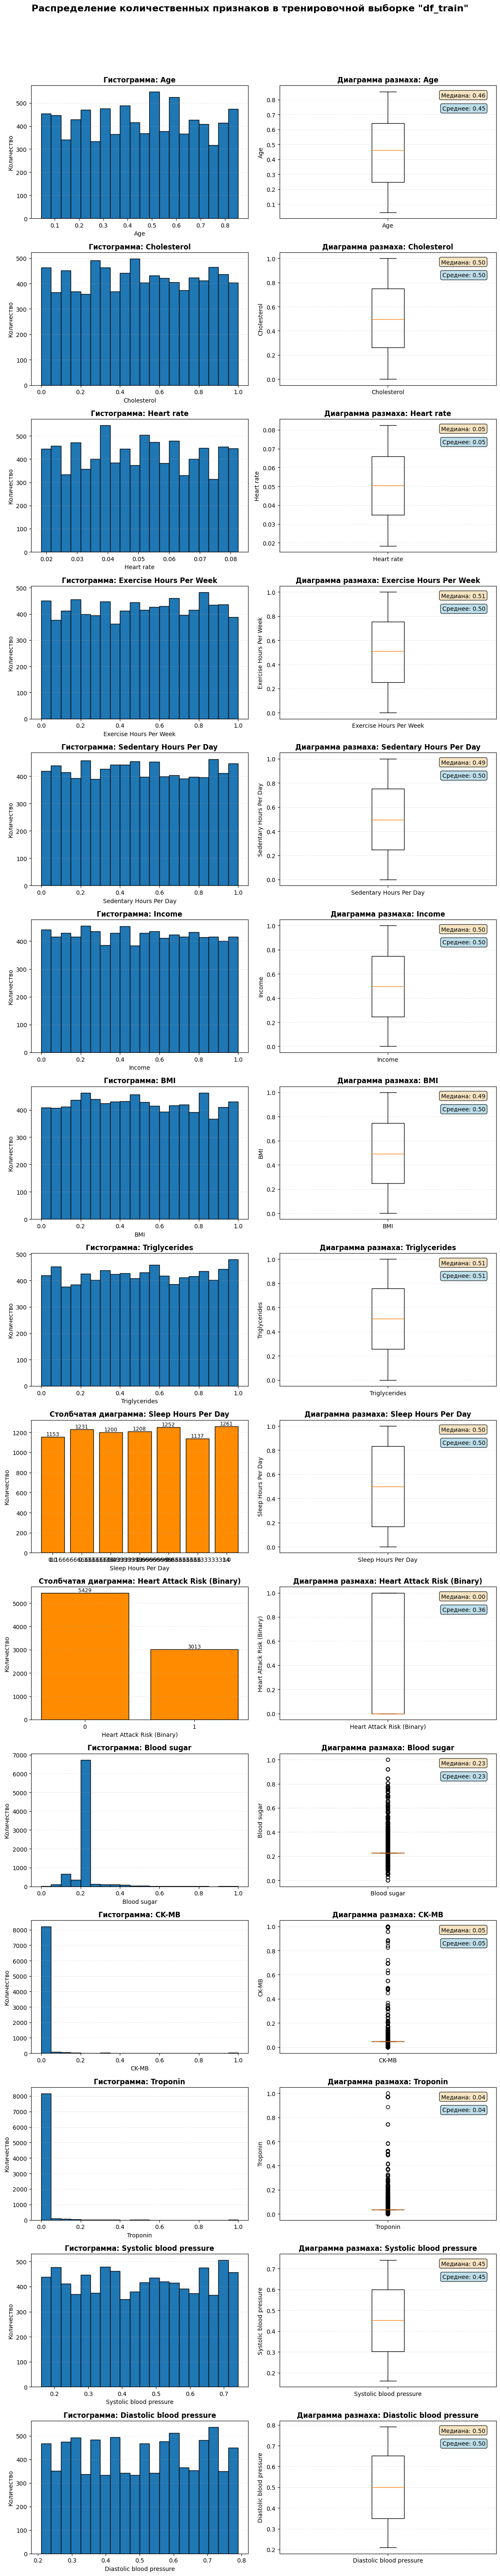

------------------------------------------------------------------------------------------------------------------------
Основные статистики выбранных количественных признаков


,count,mean,std,min,q1 (25%),median,q3 (75%),IQR,max,q1 - 1.5хIQR,q3 + 1.5хIQR
feature,,,,,,,,,,,
Age,8442,0.45,0.23,0.044944,0.247191,0.460674,0.640449,0.393258,0.853933,0.044944,0.853933
Cholesterol,8442,0.50,0.29,0.000000,0.260714,0.496429,0.750000,0.489286,1.000000,0.000000,1.000000
Heart rate,8442,0.05,0.02,0.018332,0.034830,0.050412,0.065995,0.031164,0.082493,0.018332,0.082493
Exercise Hours Per Week,8442,0.50,0.29,0.000000,0.253359,0.508244,0.754901,0.501542,1.000000,0.000000,1.000000
Sedentary Hours Per Day,8442,0.50,0.29,0.000000,0.247650,0.492734,0.751047,0.503397,1.000000,0.000000,1.000000
Income,8442,0.50,0.29,0.000000,0.244591,0.496052,0.747603,0.503012,1.000000,0.000000,1.000000
BMI,8442,0.50,0.29,0.000000,0.247935,0.490801,0.744399,0.496464,1.000000,0.000000,1.000000
Triglycerides,8442,0.51,0.29,0.000000,0.257143,0.507792,0.758442,0.501299,1.000000,0.000000,1.000000
Sleep Hours Per Day,8442,0.50,0.33,0.000000,0.166667,0.500000,0.833333,0.666667,1.000000,0.000000,1.000000


In [33]:
# Построим графики для тренировочных данных
plot_distribution_and_boxplot(df_train.drop(['id'], axis=1),
                              title='Распределение количественных признаков в тренировочной выборке "df_train"')

### Вывод по разделу

* Почти все количественные признакми имеют равномерное распределение.
* 3 признака имеют выбросы болеее 1,5 межквартильных размаха.
* Признаки содержания в крови Тропонина и КФК-МВ это маркеры уже состояшего инфаркта и являются по сути утечкой данных, поэтому их не анализируем.
* Признак содержания сахара в крови тоже имеет выбросы. Высокое содержание сахара может быть тоже результатом уже состоявшегося инфаркта. А может быть и причиной сахарного диабета. Признакми уже отмасштабированы и их сложно интепретировать. Модель Catboost хорошо справляется с выбросами.
* Целевой признак имеет дисбаланс 1:2, но это некритично. Учтем это при обучении модели.

## Обучение модели

Для решения задачи классификации будем использовать модель классификации Catboost.

In [34]:
# Определяем целевую переменную и входные признаки
X = df_train.drop(['Heart Attack Risk (Binary)', 'id', 'Income', 'CK-MB', 'Troponin'], axis=1)
y = df_train['Heart Attack Risk (Binary)']

In [35]:
# Определяем категориальные признаки (для CatBoost)
cat_features = ['Diabetes', 'Family History', 'Smoking', 'Obesity',
                'Alcohol Consumption','Stress Level', 'Gender', 'Diet',
                'Medication Use', 'Previous Heart Problems', 'Physical Activity Days Per Week'
                ]

In [36]:
# Разбиение тренировочные и валидационные данные
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Создание объектов Pool
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

Проведем анализ важности признаков. Отберем для обучения самые информативные.

### Отбор признаков по важности

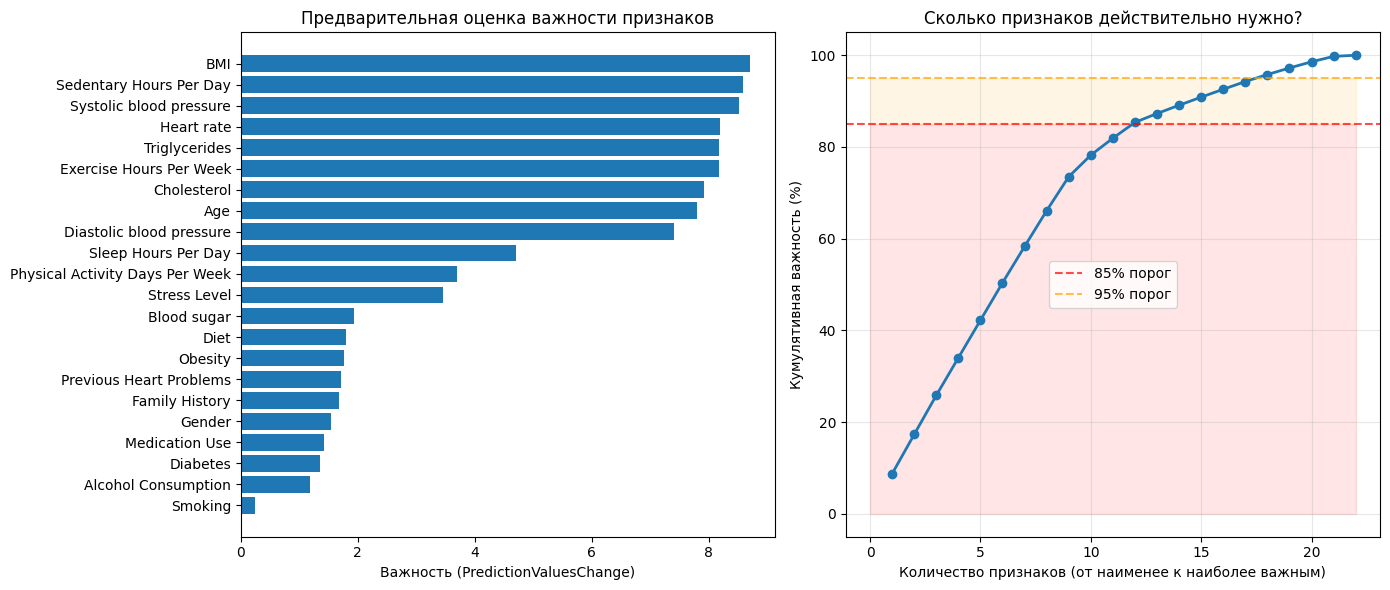

In [37]:
# Инициализация и обучение модели на всех признаках
model_initial = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function='Logloss',
    random_seed=42,
    early_stopping_rounds=500,
    auto_class_weights='Balanced',
    verbose=False
)
model_initial.fit(train_pool)

# Получаем важность (по умолчанию PredictionValuesChange)
fast_importance = model_initial.get_feature_importance()
feature_names = X_train.columns.tolist()

# Создаем DataFrame и сортируем
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': fast_importance
}).sort_values('importance', ascending=False)

# Строим графики распределения важности признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Барплот важности
axes[0].barh(range(len(importance_df)), importance_df['importance'])
axes[0].set_yticks(range(len(importance_df)))
axes[0].set_yticklabels(importance_df['feature'])
axes[0].set_xlabel('Важность (PredictionValuesChange)')
axes[0].set_title('Предварительная оценка важности признаков')
axes[0].invert_yaxis()

# График 2: Кумулятивная важность
importance_sorted = importance_df.sort_values('importance', ascending=False)
importance_sorted['cumulative'] = importance_sorted['importance'].cumsum()

axes[1].plot(range(1, len(importance_sorted)+1), importance_sorted['cumulative'], marker='o', linewidth=2)
axes[1].axhline(y=85, color='red', linestyle='--', alpha=0.7, label='85% порог')
axes[1].axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% порог')
axes[1].fill_between(range(len(importance_sorted)+1), 0, 85, alpha=0.1, color='red')
axes[1].fill_between(range(len(importance_sorted)+1), 85, 95, alpha=0.1, color='orange')
axes[1].set_xlabel('Количество признаков (от наименее к наиболее важным)')
axes[1].set_ylabel('Кумулятивная важность (%)')
axes[1].set_title('Сколько признаков действительно нужно?')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Для обучения модели будем использовать 15 признаков, которые составляют 90% кумулятивной важности. Пересоберем датасеты на новых признаках и упакуем их в объект Pool.

In [38]:
# Получаем список названий лучших признаков
top_features = importance_df.head(15)['feature'].tolist()

# 2. Создаем новые датасеты только с этими признаками
X_train_selected = X_train[top_features]
X_val_selected = X_val[top_features]

# Выделим категориальные признаки
cat_features_selected = list(X_train_selected.select_dtypes(include='category').columns)

# Создание новых объектов Pool
train_pool_selected = Pool(X_train_selected, y_train, cat_features=cat_features_selected)
val_pool_selected = Pool(X_val_selected, y_val, cat_features=cat_features_selected)

print("Выбранные признаки:")
top_features

Выбранные признаки:


['BMI',
 'Sedentary Hours Per Day',
 'Systolic blood pressure',
 'Heart rate',
 'Triglycerides',
 'Exercise Hours Per Week',
 'Cholesterol',
 'Age',
 'Diastolic blood pressure',
 'Sleep Hours Per Day',
 'Physical Activity Days Per Week',
 'Stress Level',
 'Blood sugar',
 'Diet',
 'Obesity']

In [39]:
# Список отобранных категориальных признаков
cat_features_selected

['Physical Activity Days Per Week', 'Stress Level', 'Diet', 'Obesity']

### Обучение модели на новых признаках

Метедом ручного перебора подобрали наиболее подходящие параметры для модели. Для автоматического перебора гиперпараметров потребуется много времени для вычисления. Обучим модель на отобранных признаках. Для оценки качества модели будем использовать метрику ROC-AUC для максимизации, а затем будем максимизировать Recall. Нам важно правильно найти максимально всех пациентов, кто имеет риск сердечного приступа. Но так данные очень шумные, при высоком значении Recall будет очень много ошибочных предсказаний False Positive.

In [40]:
# Инициализация новой модели
model_selected = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.04,
    depth=10,
    loss_function='Logloss',
    random_seed=42,
    eval_metric='AUC',
    early_stopping_rounds=800,
    auto_class_weights='Balanced',
    cat_features=cat_features_selected
)

model_selected.fit(
    train_pool_selected,
    eval_set=val_pool_selected,
    verbose=100
)

print(f"Лучший AUC на тесте: {model_selected.get_best_score()['validation']['AUC']}")
print(f"Точность: {model_selected.score(X_val_selected, y_val)}")

0:	test: 0.5183887	best: 0.5183887 (0)	total: 43.8ms	remaining: 2m 11s
100:	test: 0.5752667	best: 0.5752667 (100)	total: 3.2s	remaining: 1m 31s
200:	test: 0.5751109	best: 0.5802540 (179)	total: 8.47s	remaining: 1m 58s
300:	test: 0.5891705	best: 0.5891705 (300)	total: 12.6s	remaining: 1m 52s
400:	test: 0.5890544	best: 0.5927285 (307)	total: 16.8s	remaining: 1m 48s
500:	test: 0.5960376	best: 0.5966805 (498)	total: 22.9s	remaining: 1m 54s
600:	test: 0.5968928	best: 0.5979480 (587)	total: 27.1s	remaining: 1m 48s
700:	test: 0.5961201	best: 0.5979480 (587)	total: 32.2s	remaining: 1m 45s
800:	test: 0.5974746	best: 0.5980808 (734)	total: 38s	remaining: 1m 44s
900:	test: 0.6005668	best: 0.6009883 (896)	total: 42.2s	remaining: 1m 38s
1000:	test: 0.6002187	best: 0.6010723 (955)	total: 47.1s	remaining: 1m 34s
1100:	test: 0.6022008	best: 0.6022267 (1090)	total: 52.6s	remaining: 1m 30s
1200:	test: 0.5997010	best: 0.6024558 (1112)	total: 56.8s	remaining: 1m 25s
1300:	test: 0.6002339	best: 0.6024558 (

### Подбор порога вероятностей для модели

Построим таблицу метрик для разных порогов вероятностей. Так как для нас важен Recall для предсказаний мы будем использовать более низкий порог классификации.

In [41]:
# Получаем вероятности на валидационной выборке
y_pred_proba = model_selected.predict_proba(X_val_selected)[:, 1]

# Глобальный ROC-AUC (по вероятностям)
global_auc = roc_auc_score(y_val, y_pred_proba)

print("\n" + "="*62)
print(f"{'Порог':<10} {'Recall':<10} {'Precision':<10} {'F1':<10} {'Accuracy':<10} {'ROC-AUC':<10}")
print("="*62)

thresholds = np.round(np.linspace(0.1, 0.3, 20), 3).tolist()

best_recall = 0
best_threshold = 0

for threshold in thresholds:
    # Конвертируем вероятности в классы (0 или 1) по текущему порогу
    y_pred_custom = (y_pred_proba >= threshold).astype(int)

    recall = recall_score(y_val, y_pred_custom)
    precision = precision_score(y_val, y_pred_custom, zero_division=0)
    f1 = f1_score(y_val, y_pred_custom)
    acc = accuracy_score(y_val, y_pred_custom)      # Расчет Accuracy
    roc_auc_threshold = roc_auc_score(y_val, y_pred_custom)

    print(f"{threshold:<10} {recall:<10.4f} {precision:<10.4f} {f1:<10.4f} {acc:<10.4f} {roc_auc_threshold:<10.4f}")

    # Сохраняем лучший порог по Recall
    if recall > best_recall:
        best_recall = recall
        best_threshold = threshold

print("="*62)
print(f"\nГлобальный ROC-AUC (по вероятностям): {global_auc:.4f}")
print(f"Лучший порог по Recall: {best_threshold} (Recall = {best_recall:.4f})")

# --- Детальный отчёт для лучшего порога ---
print(f"\n=== Результаты для порога {best_threshold} ===")
y_pred_best = (y_pred_proba >= best_threshold).astype(int)

# 1. Текстовый отчет
print(classification_report(y_val, y_pred_best, target_names=['Нет риска', 'Есть риск']))

# 2. Дополнительные метрики для этого порога
roc_auc_best = roc_auc_score(y_val, y_pred_best)
acc_best = accuracy_score(y_val, y_pred_best)

print(f"ROC-AUC  (для порога {best_threshold}): {roc_auc_best:.4f}")
print(f"Accuracy (для порога {best_threshold}): {acc_best:.4f}")


Порог      Recall     Precision  F1         Accuracy   ROC-AUC   
0.1        0.9585     0.3778     0.5420     0.4216     0.5410    
0.111      0.9502     0.3815     0.5444     0.4322     0.5474    
0.121      0.9386     0.3835     0.5445     0.4393     0.5504    
0.132      0.9270     0.3887     0.5478     0.4535     0.5588    
0.142      0.9187     0.3932     0.5507     0.4648     0.5657    
0.153      0.8972     0.3935     0.5470     0.4695     0.5646    
0.163      0.8856     0.3961     0.5474     0.4772     0.5680    
0.174      0.8723     0.4015     0.5499     0.4902     0.5752    
0.184      0.8507     0.4039     0.5478     0.4985     0.5768    
0.195      0.8375     0.4089     0.5495     0.5098     0.5826    
0.205      0.8109     0.4095     0.5442     0.5151     0.5809    
0.216      0.7745     0.4054     0.5322     0.5139     0.5719    
0.226      0.7512     0.4056     0.5267     0.5181     0.5699    
0.237      0.7280     0.4080     0.5229     0.5258     0.5707    
0.247    

Исходя из таблицы выберем порог 0.111, чтобы определить не менее 95% пациентов с риском сердечного приступа.

In [42]:
# Устанавливаем новый порог
model_selected.set_probability_threshold(0.111)

Сохраним модель в файл запуска в приложении.

In [43]:
# Замени 'model' на имя твоей переменной, если оно другое
model_selected.save_model('model.cbm')
print("Модель сохранена в файл model.cbm")

Модель сохранена в файл model.cbm


### Вывод по разделу

* Для решения задачи классификации была выбрана модель Catboost.
* Для обучения модели были отобраны 15 признаков в поредке важности.
* Для обученной модели был снижен порог вероятности для предсказания класса "1".
* Обученная модель была сохранена в файл для развертывания в отдельном приложении.

## Общий вывод по проекту

Модель делает предсказание риска возникновения сердечного приступа (бинарная классификация).
Для работы модели необходимо 11 количественных и 4 категориальных признака:<br>

Количественные признаки:<br>
* 'BMI',
* 'Sedentary Hours Per Day',
* 'Systolic blood pressure',
* 'Heart rate',
* 'Triglycerides',
* 'Exercise Hours Per Week',
* 'Cholesterol',
* 'Age',
* 'Diastolic blood pressure',
* 'Sleep Hours Per Day',
* 'Blood sugar',

Категориальные признаки:<br>
* 'Physical Activity Days Per Week',
* 'Stress Level',
* 'Diet',
* 'Obesity'

Основные метрики качества модели: ROC-AUC и Recall (для выявления максимального количества пациентов с риском инфаркта).<br>

Модель настраивалась по максимальную метрику ROC-AUC, а затем для увеличения Recall был подобран порог отнесения к  классу "1" - 0.111. При таком значении Recall = 0.9, ROC-AUC = 0.55. При таких метриках модель делает предсказания чуть лучше baseline. Модель была обучена на не очень качественных данных, поэтому, если настроить ее на 100% предсказания всех рисковых пациентов, то будет много ложных срабатываний. Precision будет около 0.36
